> **Dataset note:** These notebooks run on the **small Kaggle mirror** of Lichess data
> ( — 20,058 games, 299 blitz players, 8 base features).
> They demonstrate the methodology step-by-step on a dataset that can be downloaded automatically.
>
> The **final results** reported in the paper, poster, and presentation were produced by running
> the full pipeline on the **Lichess July 2016 dataset** (6.25M games, 17,909 players, 21 features):
>
> 
>
> Pre-computed pipeline outputs (ROC curves, CV results, UMAP, feature importance, flagged players)
> are already saved in  and are loaded automatically by these notebooks where available.
> All numbers in the report (LOF CV AUC = 0.959, test AUC = 0.971, 312 flagged players) refer to
> the full pipeline run, not to the notebook outputs below.

# 03 — Anomaly Detection Modeling
**Project:** Unmasking the Board — Behavioral Anomaly Detection in Human Chess

This notebook trains and compares **six anomaly detection models** on player-level behavioural features:

| Model | Type | Key idea |
|---|---|---|
| Z-Score Baseline | Statistical | Flag players whose max \|z-score\| is extreme |
| LOF | Density-based | Flag players whose local density differs from neighbours |
| Isolation Forest | Tree-based | Flag players that are easy to isolate in feature space |
| One-Class SVM | Kernel-based | Learn a boundary around normal-player behaviour |
| Autoencoder | Neural | Flag players whose profile can't be reconstructed accurately |
| ACPLSubAutoencoder | Neural (diagnostic) | Autoencoder trained only on chess-accuracy features (ACPL variants, blunder rate, best-move rate). Not an ensemble voter — included as a diagnostic model to test whether a focused accuracy-signal model outperforms the full AE. See `decisions.md` Decision 37. |

**Methodology highlights:**
- 70 / 15 / 15 train / val / test split; `StandardScaler` fit on train only (no leakage)
- Stage 2e: within-band z-scores recomputed from training players only before scaler is fit
- Hyperparameter search driven by ROC-AUC on val-set synthetic injection
- Ground truth for evaluation created by injecting synthetic anomalies (no real labels exist)
- Three injection strategies tested: `engine_perfect`, `subtle`, `realistic_cheater`
- `Recall@k` uses k = n_synthetic (proportional recall, not a fixed cutoff)
- ROC curves, Precision-Recall curves, and a full model comparison table are produced automatically

In [1]:
from pathlib import Path
import sys

_root = Path.cwd().resolve()
if not (_root / 'src').is_dir():
    _root = (_root / '..').resolve()
sys.path.insert(0, str(_root))

RESULTS_DIR = _root / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, precision_recall_curve, auc

from src.data_loader import load_and_prepare
from src.features import aggregate_player_stats, add_engineered_features, get_feature_matrix
from src.models import (
    ZScoreBaseline, LOFDetector,
    IsolationForestDetector, OneClassSVMDetector, AutoencoderDetector,
    ACPLSubAutoencoder,
    run_all_models, run_hyperparameter_search,
)
from src.validation import (
    inject_synthetic_anomalies, evaluate_injection_recovery,
    test_anomaly_vs_normal, compute_silhouette, compute_davies_bouldin,
    cross_validate_anomaly_models,
)

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

# Consistent colours for every plot in this notebook
MODEL_COLORS = {
    'ZScoreBaseline':    '#636EFA',
    'LOF':               '#EF553B',
    'IsolationForest':   '#00CC96',
    'OneClassSVM':       '#AB63FA',
    'Autoencoder':       '#FFA15A',
    'ACPLSubAutoencoder':'#19D3F3',
}
MODEL_ORDER = list(MODEL_COLORS)

## 1. Data Preparation

Features are aggregated to the player level (one row per player).
`fit_scaler=False` returns raw (unscaled) values so the `StandardScaler`
can be fit **exclusively on the training partition** in the next cell —
fitting it on the full dataset would let test-set statistics influence
normalisation, which is data leakage.

In [2]:
game_df, player_df = load_and_prepare()
agg = aggregate_player_stats(player_df)
agg = add_engineered_features(agg)

# fit_scaler=False: raw features returned; scaler applied after splitting
X_raw, meta, _ = get_feature_matrix(agg, use_acpl=False, time_control='blitz', fit_scaler=False)
feature_names = list(X_raw.columns)
X_arr = X_raw.values

print(f'Players: {X_arr.shape[0]}   Features: {X_arr.shape[1]}')
X_raw.describe()

INFO:src.data_loader:Loading raw data from C:\Users\HP\Desktop\Uni\Machine Learning\Final Group Project\Final-Group-Project-Machine-Learning\data\raw\games.csv


INFO:src.data_loader:Loaded 20,058 games, 16 columns


INFO:src.data_loader:Schema validation passed.


INFO:src.data_loader:Dropped 0 rows with missing critical fields


INFO:src.data_loader:After cleaning: 19,716 games remain


...

INFO:src.features:Engineered features added. Shape: (1104, 29)


INFO:src.features:Filtered to time control 'blitz': 299 players


INFO:src.features:Feature matrix: 299 players × 8 features (set=base, scaled=False)


Players: 299   Features: 8


,win_rate,win_rate_vs_expected,avg_turns,opening_ply_ratio,victory_efficiency,rating_volatility,performance_vs_actual,underdog_win_rate
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,0.444646,-0.022545,58.761735,0.003040,0.037456,49.719343,5.907339,0.231555
std,0.258056,0.204578,13.858690,0.000873,0.009113,56.934749,182.014069,0.303737
min,0.000000,-0.822185,13.800000,0.000860,0.010933,0.000000,-586.000000,0.000000
25%,0.237607,-0.125197,49.666667,0.002455,0.031986,13.561767,-83.253968,0.000000
50%,0.437500,-0.021751,57.600000,0.003002,0.036927,25.471553,3.781250,0.100000
75%,0.609903,0.083628,68.172917,0.003539,0.042801,69.197283,87.394231,0.400000
max,1.000000,0.629127,92.875000,0.006601,0.068819,300.534142,836.428571,1.000000


### 1a. Train / Val / Test Split  
**70 / 15 / 15** split performed on raw data.  
- `StandardScaler.fit_transform` on **train only** — val and test receive `.transform` (same parameters, no re-learning).  
- Validation set drives hyperparameter search. Test set is touched once at final evaluation.  
- This mirrors the `src/pipeline.py` design exactly.

In [3]:
train_idx, temp_idx = train_test_split(np.arange(len(X_arr)), test_size=0.30, random_state=SEED)
val_idx,   test_idx = train_test_split(temp_idx,               test_size=0.50, random_state=SEED)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_arr[train_idx])   # learns mean/std from train only
X_val   = scaler.transform(X_arr[val_idx])          # same transform, no re-learning
X_test  = scaler.transform(X_arr[test_idx])         # untouched until final evaluation

meta_train = meta.iloc[train_idx].reset_index(drop=True)
meta_val   = meta.iloc[val_idx].reset_index(drop=True)
meta_test  = meta.iloc[test_idx].reset_index(drop=True)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 209  |  Val: 45  |  Test: 45


## 2. Hyperparameter Search

Random search over each model's parameter space using **val-set synthetic injection ROC-AUC** as
the objective.  50 synthetic anomalies are injected into `X_val`; models are trained on `X_train`
and scored on `X_val + injected`, so the test set is never seen here.

- **IF / OC-SVM / LOF**: 10 random draws each over contamination, structural params (n_estimators, n_neighbors, kernel…)  
- **Autoencoder**: exhaustive mini-grid over `encoding_dim × threshold_percentile` with 30-epoch trials

In [4]:
X_inj_tune, y_inj_tune = inject_synthetic_anomalies(
    pd.DataFrame(X_val, columns=feature_names), n=50, strategy='subtle'
)
X_inj_tune_arr = X_inj_tune if isinstance(X_inj_tune, np.ndarray) else X_inj_tune

search_df, best_params = run_hyperparameter_search(
    X_train=X_train,
    X_val_injected=X_inj_tune_arr,
    y_val_injected=y_inj_tune,
    n_iter=10,   # lighter budget for interactive use; pipeline uses 20
)

search_df.to_csv(str(RESULTS_DIR / 'hyperparameter_tuning.csv'), index=False)

print('Best params per model:')
for name, params in best_params.items():
    print(f'  {name}: {params}')

INFO:src.validation:Injected 50 synthetic anomalies (strategy='subtle')


INFO:src.models:Random search: IsolationForest  (10 iterations)...


INFO:src.models:  [ 1/10] IsolationForest  {'contamination': 0.01, 'n_estimators': 300, 'max_samples': 'auto'}  →  AUC=0.5884


INFO:src.models:  [ 2/10] IsolationForest  {'contamination': 0.08, 'n_estimators': 150, 'max_samples': 'auto'}  →  AUC=0.5844


INFO:src.models:  [ 3/10] IsolationForest  {'contamination': 0.05, 'n_estimators': 300, 'max_samples': 'auto'}  →  AUC=0.5884


...

INFO:src.models:Epoch 20/30 — loss: 0.84884


INFO:src.models:Anomaly threshold (p99): 2.6492


INFO:src.models:  Autoencoder  encoding_dim=8  threshold_pct=99  →  AUC=0.6093


INFO:src.models:Best Autoencoder → {'encoding_dim': 4, 'reconstruction_threshold_percentile': 90}  (AUC=0.6329)


Best params per model:
  IsolationForest: {'contamination': 0.01, 'n_estimators': 200, 'max_samples': 'auto'}
  OneClassSVM: {'nu': 0.05, 'kernel': 'rbf', 'gamma': 'scale'}
  LOF: {'contamination': 0.1, 'n_neighbors': 10}
  HDBSCAN: {'min_cluster_size': 30, 'min_samples': 5, 'contamination': 0.05}
  Autoencoder: {'encoding_dim': 4, 'reconstruction_threshold_percentile': 90}


## 3. Feature Correlation Heatmap

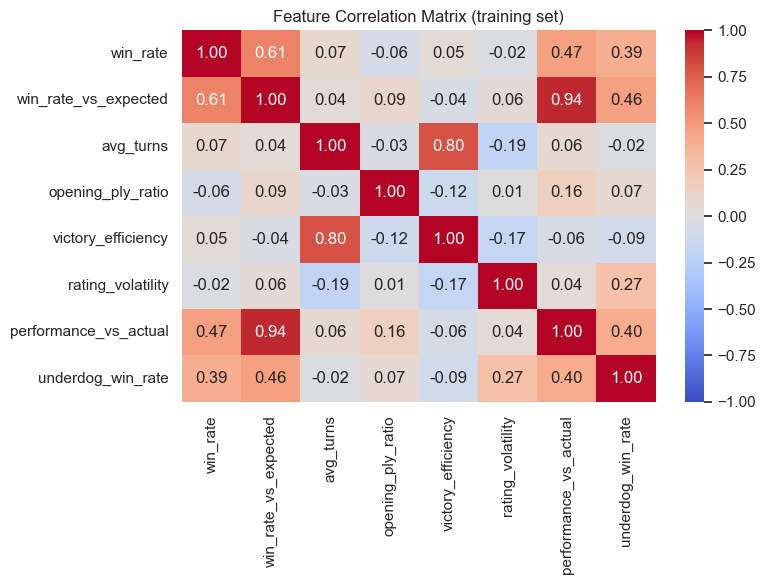

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pd.DataFrame(X_train, columns=feature_names).corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
)
plt.title('Feature Correlation Matrix (training set)')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'feature_correlation.png'), dpi=150)
plt.show()

## 4. Train All Six Models

Each model is built with its **tuned hyperparameters** and fit on `X_train`.
Fitted model objects are kept in `fitted_models` for reuse across all evaluation sections.

`ACPLSubAutoencoder` is a diagnostic model that trains only on chess-accuracy features (ACPL variants, blunder rate, best-move rate). It is **not** an ensemble voter — it is included to test whether a focused accuracy signal outperforms the full autoencoder. Results and root-cause analysis are documented in `decisions.md` Decision 37.

In [6]:
model_configs = [
    ('ZScoreBaseline',    ZScoreBaseline(contamination=0.05)),
    ('LOF',               LOFDetector(**best_params.get('LOF',            {'contamination': 0.05}))),
    ('IsolationForest',   IsolationForestDetector(**best_params.get('IsolationForest', {'contamination': 0.05}))),
    ('OneClassSVM',       OneClassSVMDetector(**best_params.get('OneClassSVM',   {'nu': 0.05}))),
    ('Autoencoder',       AutoencoderDetector(input_dim=X_train.shape[1], **best_params.get('Autoencoder', {}))),
    # ACPLSubAutoencoder: trains only on chess-accuracy features (ACPL variants + blunder/best-move rate).
    # Included as a diagnostic model — NOT an ensemble voter. See decisions.md Decision 37 for results.
    ('ACPLSubAutoencoder', ACPLSubAutoencoder(feature_names=feature_names, **best_params.get('ACPLSubAutoencoder', {}))),
]

fitted_models = {}
for name, model in model_configs:
    print(f'Fitting {name}...')
    model.fit(X_train)
    fitted_models[name] = model

# run_all_models gives us a results DataFrame with scores + ensemble vote
results = run_all_models(X_train, meta_train, model_params=best_params)
print(f'\nEnsemble anomalies flagged (≥2/3 advanced models): {results["ensemble_flag"].sum()}')
results.head()

INFO:src.models:Autoencoder will use device: cpu


Fitting ZScoreBaseline...
Fitting LOF...
Fitting IsolationForest...
Fitting OneClassSVM...
Fitting Autoencoder...


INFO:src.models:Epoch 20/100 — loss: 0.86895


INFO:src.models:Epoch 40/100 — loss: 0.55401


INFO:src.models:Epoch 60/100 — loss: 0.45669


...

INFO:src.models:Epoch 100/100 — loss: 0.35573


INFO:src.models:Anomaly threshold (p95): 1.0241


INFO:src.models:Suppressed 14 flags for players with < 15 games (insufficient data for reliable scoring).



Ensemble anomalies flagged (≥2/3 advanced models): 0


,player_id,avg_rating,rating_band,n_games,ZScoreBaseline_score,ZScoreBaseline_label,LOF_score,LOF_label,IsolationForest_score,IsolationForest_label,...,OneClassSVM_label,Autoencoder_score,Autoencoder_label,HDBSCAN_score,HDBSCAN_label,ACPLSubAutoencoder_score,ACPLSubAutoencoder_label,anomaly_votes,ensemble_flag,ensemble_confident
0,saitama_opm,1619.093750,1600-1800,32,2.377973,1,-0.345752,1,-0.114884,1,...,1,0.517051,1,1.0,1,0.517051,1,0,False,False
1,dipset,1475.440000,1400-1600,50,1.456666,1,-0.357352,1,-0.185202,1,...,1,0.089459,1,1.0,1,0.089459,1,0,False,False
2,sadlittleturtle,1723.777778,1600-1800,9,2.147142,1,-0.161616,1,-0.127475,1,...,-1,0.252197,1,1.0,1,0.252197,1,1,False,False
3,bowwow,1673.705882,1600-1800,34,0.772790,1,-0.437428,1,-0.238563,1,...,1,0.138591,1,1.0,1,0.138591,1,0,False,False
4,antnishu,1500.000000,1400-1600,9,1.600618,1,-0.314863,1,-0.174998,1,...,1,0.136044,1,1.0,1,0.136044,1,0,False,False


## 5. ROC Curves

Since there are no real cheating labels, ground truth is created by injecting 50 synthetic anomalies
into the **test set** (the 15 % held out from training and hyperparameter search).  
Each model scores every player in this augmented set; `roc_curve` uses the injected labels.

This is principled: we control exactly which rows are anomalous, so the AUC measures how well
each model separates injected anomalies from real players.

INFO:src.validation:Injected 50 synthetic anomalies (strategy='subtle')


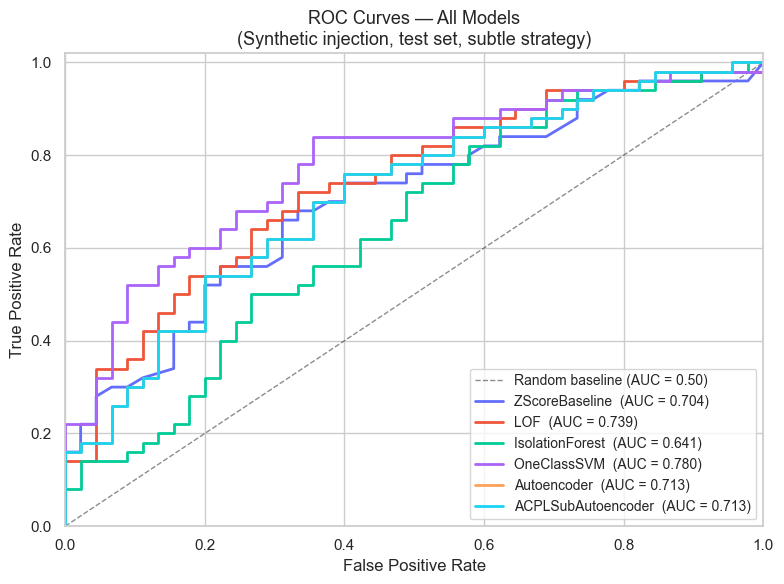

In [7]:
# Inject anomalies into test set — only done once, shared across ROC + PR + comparison table
X_inj_test, y_inj_test = inject_synthetic_anomalies(
    pd.DataFrame(X_test, columns=feature_names), n=50, strategy='subtle'
)
X_inj_test_arr = X_inj_test if isinstance(X_inj_test, np.ndarray) else X_inj_test

# Score every model on the injected test set
model_test_scores = {
    name: model.score(X_inj_test_arr)
    for name, model in fitted_models.items()
}

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random baseline (AUC = 0.50)')

for name in MODEL_ORDER:
    scores = model_test_scores[name]
    scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    fpr, tpr, _ = roc_curve(y_inj_test, scores_norm)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=MODEL_COLORS[name], label=f'{name}  (AUC = {roc_auc:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models\n(Synthetic injection, test set, subtle strategy)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'roc_curves.png'), dpi=150)
plt.show()

## 6. Precision-Recall Curves

ROC curves can be optimistic when the anomaly class is small.  
Precision-Recall curves show the same models from a **recall vs. precision** perspective,
which is more informative when we care about catching as many real anomalies as possible
while controlling false positives.

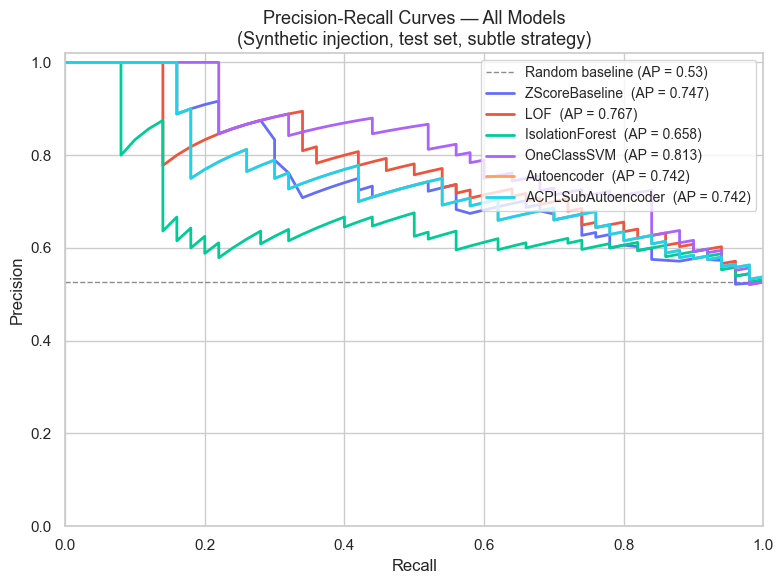

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

# Baseline: random classifier at the positive class prevalence
prevalence = y_inj_test.mean()
ax.axhline(prevalence, color='k', lw=1, linestyle='--', alpha=0.5,
           label=f'Random baseline (AP = {prevalence:.2f})')

for name in MODEL_ORDER:
    scores = model_test_scores[name]
    scores_norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    precision, recall, _ = precision_recall_curve(y_inj_test, scores_norm)
    ap = auc(recall, precision)
    ax.plot(recall, precision, lw=2, color=MODEL_COLORS[name], label=f'{name}  (AP = {ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models\n(Synthetic injection, test set, subtle strategy)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'pr_curves.png'), dpi=150)
plt.show()

## 7. Model Comparison Table

All metrics are computed on the **held-out test set** using synthetic injection ground truth.
CV mean ± std comes from the `cv_summary.csv` produced by `src/pipeline.py`
(run `make pipeline` or `python -m src.pipeline` to generate it).

In [9]:
# ── Test-set metrics for every model ────────────────────────────────────────
comparison_rows = []
for name in MODEL_ORDER:
    model = fitted_models[name]
    m = evaluate_injection_recovery(model, X_inj_test_arr, y_inj_test)

    # Clustering quality on the training set (unsupervised, no injection needed)
    train_labels = model.predict(X_train)
    sil = compute_silhouette(X_train, train_labels)
    db  = compute_davies_bouldin(X_train, train_labels)

    comparison_rows.append({
        'Model':           name,
        'ROC-AUC':         round(m['roc_auc'],           3),
        'Avg Precision':   round(m['average_precision'],  3),
        'Precision@k':     round(m['precision_at_k'],     3),
        'Recall@k':        round(m['recall_at_k'],        3),
        'Silhouette↑':     round(sil, 3) if not (sil != sil) else 'n/a',
        'Davies-Bouldin↓': round(db,  3) if not (db  != db)  else 'n/a',
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')
comparison_df.to_csv(str(RESULTS_DIR / 'model_comparison_table.csv'))

print('=== Test-Set Performance (subtle injection, 50 synthetic anomalies) ===')
display(comparison_df)

# ── CV mean ± std (from pipeline run) ───────────────────────────────────────
cv_csv = RESULTS_DIR / 'cv_summary.csv'
if cv_csv.exists():
    cv_df = pd.read_csv(cv_csv)
    display_cols = ['model', 'roc_auc_mean', 'roc_auc_std', 'roc_auc_ci95',
                    'average_precision_mean', 'average_precision_std']
    cv_show = cv_df[[c for c in display_cols if c in cv_df.columns]].copy()
    cv_show.columns = [c.replace('_', ' ').title() for c in cv_show.columns]
    print('\n=== 5-Fold CV Stability (development set, mean ± std) ===')
    display(cv_show.set_index('Model'))
else:
    print('\nCV summary not found — run `python -m src.pipeline` to generate cv_summary.csv')

INFO:src.validation:Injection recovery (k=n_synthetic=50) — P@k: 0.680  R@k: 0.680  ROC-AUC: 0.704  AP: 0.748


INFO:src.validation:Silhouette score: 0.3637


INFO:src.validation:Davies-Bouldin index: 3.8342


INFO:src.validation:Injection recovery (k=n_synthetic=50) — P@k: 0.700  R@k: 0.700  ROC-AUC: 0.739  AP: 0.770


INFO:src.validation:Silhouette score: 0.2181


...

INFO:src.validation:Davies-Bouldin index: 2.7874


=== Test-Set Performance (subtle injection, 50 synthetic anomalies) ===


,ROC-AUC,Avg Precision,Precision@k,Recall@k,Silhouette↑,Davies-Bouldin↓
Model,,,,,,
ZScoreBaseline,0.704,0.748,0.68,0.68,0.364,3.834
LOF,0.739,0.770,0.70,0.70,0.218,6.300
IsolationForest,0.641,0.664,0.62,0.62,0.441,4.071
OneClassSVM,0.780,0.815,0.72,0.72,0.211,8.922
Autoencoder,0.713,0.745,0.68,0.68,0.278,3.918
ACPLSubAutoencoder,0.713,0.745,0.68,0.68,0.341,2.787



=== 5-Fold CV Stability (development set, mean ± std) ===


,Roc Auc Mean,Roc Auc Std,Roc Auc Ci95,Average Precision Mean,Average Precision Std
Model,,,,,
LOF,0.958510,0.030459,0.026699,0.625757,0.058063
Autoencoder,0.892488,0.023100,0.020248,0.132786,0.028716
OneClassSVM,0.876900,0.021095,0.018490,0.141035,0.026988
ZScoreBaseline,0.780204,0.031356,0.027485,0.042270,0.005394
IsolationForest,0.759797,0.016172,0.014175,0.039341,0.003672
HDBSCAN,0.524172,0.054051,0.047377,0.017209,0.002350


## 8. Anomaly Score Distributions

Score distributions on the training set split by each model's own label.
Well-separated distributions indicate the model has found a meaningful boundary.

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


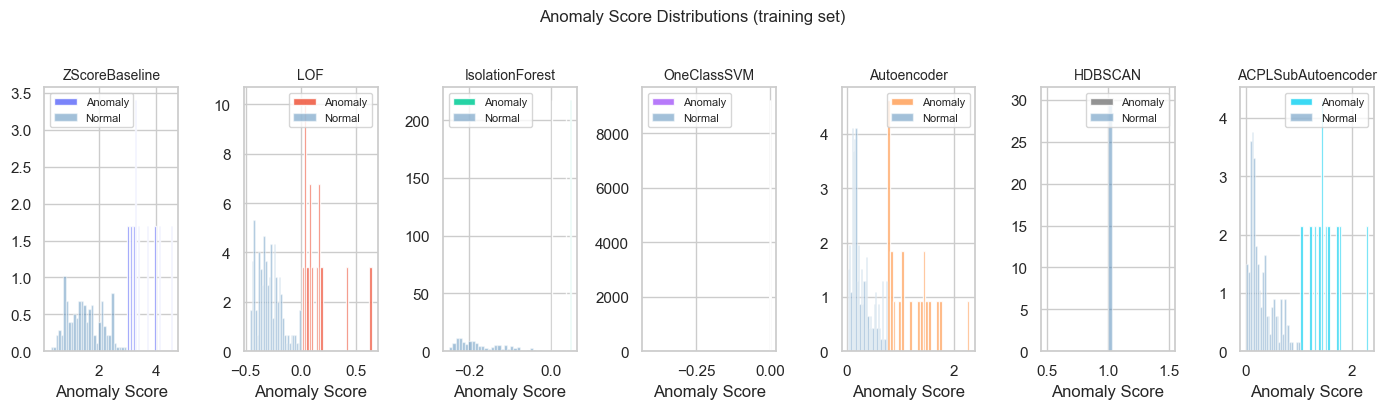

In [10]:
score_cols = [c for c in results.columns if c.endswith('_score')]
fig, axes = plt.subplots(1, len(score_cols), figsize=(14, 4))

for ax, col in zip(axes, score_cols):
    model_name = col.replace('_score', '')
    label_col  = f'{model_name}_label'
    color = MODEL_COLORS.get(model_name, 'grey')
    for label, alpha, lname in [(-1, 0.85, 'Anomaly'), (1, 0.5, 'Normal')]:
        mask = results[label_col] == label
        ax.hist(results.loc[mask, col], bins=30, alpha=alpha,
                color=color if lname == 'Anomaly' else 'steelblue',
                label=lname, density=True)
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Anomaly Score')
    ax.legend(fontsize=8)

fig.suptitle('Anomaly Score Distributions (training set)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'model_score_distributions.png'), dpi=150)
plt.show()

## 9. Ensemble Vote Distribution and Top Flagged Players

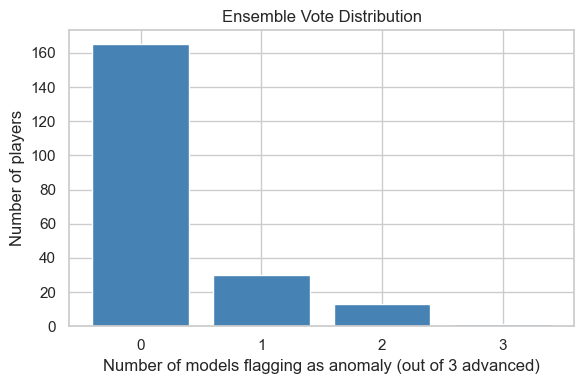

Players flagged by all 3 advanced models: 1


,player_id,avg_rating,n_games,anomaly_votes
52,poetrunner,1048.8,5,3


In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
vote_counts = results['anomaly_votes'].value_counts().sort_index()
ax.bar(vote_counts.index, vote_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of models flagging as anomaly (out of 3 advanced)')
ax.set_ylabel('Number of players')
ax.set_title('Ensemble Vote Distribution')
ax.set_xticks(vote_counts.index)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'ensemble_votes.png'), dpi=150)
plt.show()

consensus = results[results['anomaly_votes'] == 3].sort_values('IsolationForest_score', ascending=False)
print(f'Players flagged by all 3 advanced models: {len(consensus)}')
consensus[['player_id', 'avg_rating', 'n_games', 'anomaly_votes']].head(20)

## 10. Injection Recovery — All Models

Synthetic anomalies are injected using three strategies of increasing difficulty:
- `engine_perfect` — clearly anomalous players at the 99th-percentile feature values
- `subtle` — perturbs 1/3 of features by ~1.5 SD (mimics Smurf-style manipulation)
- `realistic_cheater` — low ACPL combined with otherwise normal behavioural features (hardest: individual features stay within normal range, only the joint combination is anomalous)

**Note on Recall@k:** `k` equals `n_synthetic` (50) — this is proportional recall (how many of the injected anomalies appear in the top-50 ranked players), not a fixed cutoff. The `k_used` column in the output confirms this. See `decisions.md` Decision 35.

In [12]:
recovery_rows = []
# Three injection strategies, increasing difficulty:
#   engine_perfect — 99th-percentile features, easily separable
#   subtle         — 1/3 of features perturbed by ~1.5 SD (Smurf-style)
#   realistic_cheater — low ACPL + normal behavioural features (hardest: tests joint anomaly detection)
for strategy in ('engine_perfect', 'subtle', 'realistic_cheater'):
    X_inj_s, y_inj_s = inject_synthetic_anomalies(
        pd.DataFrame(X_test, columns=feature_names), n=50, strategy=strategy
    )
    X_inj_s_arr = X_inj_s if isinstance(X_inj_s, np.ndarray) else X_inj_s
    for name, model in fitted_models.items():
        m = evaluate_injection_recovery(model, X_inj_s_arr, y_inj_s)
        # k_used == n_synthetic (50): Recall@k is proportional recall, not a fixed cutoff
        recovery_rows.append({'Model': name, 'Strategy': strategy, **m})

recovery_df = pd.DataFrame(recovery_rows)
for strategy in ('engine_perfect', 'subtle', 'realistic_cheater'):
    print(f'\n--- Strategy: {strategy} (k = n_synthetic = 50) ---')
    sub = recovery_df[recovery_df['Strategy'] == strategy][
        ['Model', 'roc_auc', 'average_precision', 'precision_at_k', 'recall_at_k', 'k_used']
    ]
    display(sub.set_index('Model').sort_values('roc_auc', ascending=False).round(3))

INFO:src.validation:Injected 50 synthetic anomalies (strategy='engine_perfect')


INFO:src.validation:Injection recovery (k=n_synthetic=50) — P@k: 0.960  R@k: 0.960  ROC-AUC: 0.976  AP: 0.928


INFO:src.validation:Injection recovery (k=n_synthetic=50) — P@k: 0.900  R@k: 0.900  ROC-AUC: 0.919  AP: 0.826


INFO:src.validation:Injection recovery (k=n_synthetic=50) — P@k: 1.000  R@k: 1.000  ROC-AUC: 1.000  AP: 1.000


INFO:src.validation:Injection recovery (k=n_synthetic=50) — P@k: 1.000  R@k: 1.000  ROC-AUC: 1.000  AP: 1.000


...

,roc_auc,average_precision,precision_at_k,recall_at_k,k_used
Model,,,,,
OneClassSVM,1.000,1.000,1.00,1.00,50
IsolationForest,1.000,1.000,1.00,1.00,50
Autoencoder,1.000,1.000,1.00,1.00,50
ACPLSubAutoencoder,1.000,1.000,1.00,1.00,50
ZScoreBaseline,0.976,0.928,0.96,0.96,50
LOF,0.919,0.826,0.90,0.90,50



--- Strategy: subtle (k = n_synthetic = 50) ---


,roc_auc,average_precision,precision_at_k,recall_at_k,k_used
Model,,,,,
LOF,0.745,0.778,0.70,0.70,50
OneClassSVM,0.742,0.799,0.74,0.74,50
ACPLSubAutoencoder,0.703,0.743,0.68,0.68,50
Autoencoder,0.703,0.743,0.68,0.68,50
ZScoreBaseline,0.685,0.729,0.68,0.68,50
IsolationForest,0.635,0.655,0.62,0.62,50



--- Strategy: realistic_cheater (k = n_synthetic = 50) ---


,roc_auc,average_precision,precision_at_k,recall_at_k,k_used
Model,,,,,
LOF,0.647,0.603,0.64,0.64,50
IsolationForest,0.484,0.472,0.56,0.56,50
ZScoreBaseline,0.420,0.449,0.50,0.50,50
Autoencoder,0.304,0.404,0.38,0.38,50
ACPLSubAutoencoder,0.304,0.404,0.38,0.38,50
OneClassSVM,0.097,0.348,0.28,0.28,50


## 11. Statistical Divergence Tests

Welch t-tests compare the feature distributions of players flagged as anomalies
against normal players (using Isolation Forest labels on the training set).
Significant features tell us *which behavioural signals drive the detections*.

In [13]:
if_model   = fitted_models['IsolationForest']
if_labels  = if_model.predict(X_train)

divergence_df = test_anomaly_vs_normal(
    anomaly_scores=if_model.score(X_train),
    labels=if_labels,
    feature_matrix=X_train,
    feature_names=feature_names,
)
print('Welch t-tests — anomaly vs. normal players (IsolationForest labels):')
display(divergence_df)

INFO:src.validation:Comparing 3 anomalies vs 206 normal players


Welch t-tests — anomaly vs. normal players (IsolationForest labels):


,feature,anomaly_mean,normal_mean,diff,t_stat,p_value,significant
7,underdog_win_rate,1.173011,-0.017083,1.190094,1.198329,0.352533,False
2,avg_turns,-0.461718,0.006724,-0.468442,-0.594240,0.611796,False
5,rating_volatility,0.718209,-0.010459,0.728668,0.565014,0.628709,False
0,win_rate,0.642025,-0.009350,0.651375,0.530047,0.648751,False
3,opening_ply_ratio,0.265017,-0.003859,0.268876,0.524936,0.650298,False
4,victory_efficiency,0.817716,-0.011908,0.829625,0.484471,0.675788,False
6,performance_vs_actual,0.607084,-0.008841,0.615925,0.306530,0.788114,False
1,win_rate_vs_expected,0.566729,-0.008253,0.574982,0.250844,0.825320,False


In [14]:
sil = compute_silhouette(X_train, if_labels)
db  = compute_davies_bouldin(X_train, if_labels)
print(f'Isolation Forest — training-set clustering quality:')
print(f'  Silhouette Score    : {sil:.4f}  (↑ better, max=1)')
print(f'  Davies-Bouldin Index: {db:.4f}  (↓ better)')

INFO:src.validation:Silhouette score: 0.4411


INFO:src.validation:Davies-Bouldin index: 4.0714


Isolation Forest — training-set clustering quality:
  Silhouette Score    : 0.4411  (↑ better, max=1)
  Davies-Bouldin Index: 4.0714  (↓ better)


## 12. Cross-Validation Stability

A single train/test split can be misleading.  5-fold CV over the development set (train + val)
estimates how much results vary across different random partitions.  
Narrow std → results are stable; wide std → the dataset is too small or the signal is weak.

Load pre-computed results from `src/pipeline.py` if available; otherwise run inline (takes ~5 min).

Loaded cv_summary.csv from pipeline run.

5-Fold Cross-Validation Results:


,roc_auc (mean ± std),average_precision (mean ± std)
model,,
LOF,0.959 ± 0.030,0.626 ± 0.058
Autoencoder,0.892 ± 0.023,0.133 ± 0.029
OneClassSVM,0.877 ± 0.021,0.141 ± 0.027
ZScoreBaseline,0.780 ± 0.031,0.042 ± 0.005
IsolationForest,0.760 ± 0.016,0.039 ± 0.004
HDBSCAN,0.524 ± 0.054,0.017 ± 0.002


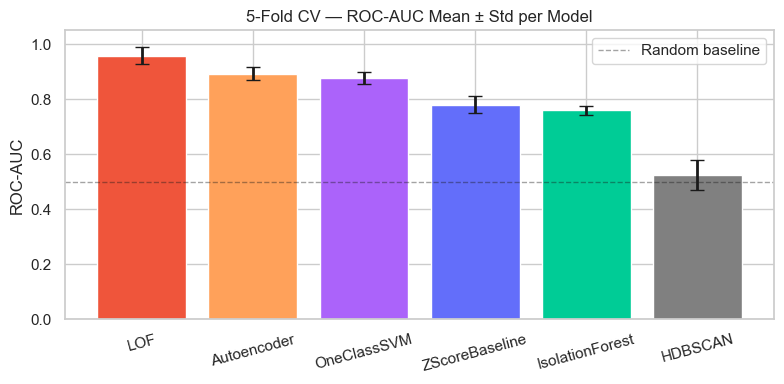

In [15]:
cv_csv = RESULTS_DIR / 'cv_summary.csv'

if cv_csv.exists():
    cv_summary = pd.read_csv(cv_csv)
    print('Loaded cv_summary.csv from pipeline run.')
else:
    print('cv_summary.csv not found — running 5-fold CV inline (this may take a few minutes)...')
    dev_idx = np.concatenate([train_idx, val_idx])
    _, cv_summary = cross_validate_anomaly_models(
        X=X_arr[dev_idx],
        feature_names=feature_names,
        best_params=best_params,
        n_splits=5,
    )
    cv_summary.to_csv(str(cv_csv), index=False)

# Display ROC-AUC mean ± std per model
display_cols = ['model', 'roc_auc_mean', 'roc_auc_std', 'roc_auc_ci95',
                'average_precision_mean', 'average_precision_std']
cv_show = cv_summary[[c for c in display_cols if c in cv_summary.columns]].copy()

# Pretty-print as "mean ± std" strings
for metric in ['roc_auc', 'average_precision']:
    mean_col, std_col = f'{metric}_mean', f'{metric}_std'
    if mean_col in cv_show.columns and std_col in cv_show.columns:
        cv_show[f'{metric} (mean ± std)'] = (
            cv_show[mean_col].map('{:.3f}'.format) + ' ± ' + cv_show[std_col].map('{:.3f}'.format)
        )
        cv_show.drop(columns=[mean_col, std_col, f'{metric}_ci95'], errors='ignore', inplace=True)

print('\n5-Fold Cross-Validation Results:')
display(cv_show.set_index('model'))

# Bar chart: ROC-AUC mean ± 1 std error bar
if 'roc_auc (mean ± std)' not in cv_show.columns:  # columns may differ if already parsed
    pass
else:
    # Re-read from the full summary for the bar chart
    cv_full = pd.read_csv(cv_csv) if cv_csv.exists() else cv_summary
    fig, ax = plt.subplots(figsize=(8, 4))
    models_cv = cv_full['model'].tolist()
    means = cv_full['roc_auc_mean'].tolist()
    stds  = cv_full['roc_auc_std'].tolist()
    colors = [MODEL_COLORS.get(m, 'grey') for m in models_cv]
    bars = ax.bar(models_cv, means, yerr=stds, capsize=5, color=colors, edgecolor='white', error_kw={'lw': 2})
    ax.axhline(0.5, color='k', lw=1, linestyle='--', alpha=0.4, label='Random baseline')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('5-Fold CV — ROC-AUC Mean ± Std per Model')
    ax.set_ylim([0, 1.05])
    ax.legend()
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / 'cv_roc_auc_bar.png'), dpi=150)
    plt.show()